# 第29篇｜描述性统计：均值 / 方差 / 偏度 / 峰度

> 这是「数据分析从入门到精通」系列的第 29 篇，也是统计学基础阶段的开篇。可视化做漂亮了，但图表背后的数字是什么含义？这篇从最基础的均值、方差讲起，一直到偏度、峰度，彻底搞懂"描述一组数据"到底描述的是什么。

---

嗨，我是小荷～

第三阶段开始了！这个阶段叫**统计学基础**，很多人跳过这里直接去学机器学习，然后就遇到了各种"为什么模型效果这么差"的困惑。

统计学是数据分析的地基。没有地基，楼再高也会塌。

今天第一篇，讲**描述性统计**。这些指标你可能都听说过——均值、方差……但它们的真正含义、局限性，以及它们组合起来能告诉你什么，值得好好讲清楚。

> 萧何管粮草，第一件事不是分配，而是**摸清家底**。均值、方差、偏度——就是数据的"家底"。

---

## 一、为什么需要描述性统计？

给你 1000 行数据，你能"理解"它吗？不能。

给你这几个数字：均值 ¥520、中位数 ¥380、标准差 ¥310、偏度 1.8——你马上知道：这是一个右偏分布，大多数人消费不高，少数高消费用户拉高了均值。

描述性统计把 1000 行数据压缩成几个关键指标，让你快速理解数据的"轮廓"。

---

## 二、集中趋势：数据的"重心"

### 均值（Mean）

均值是最基础的统计量，但要注意它的"坑"：


In [1]:
import numpy as np
import pandas as pd
from scipy import stats

data = [200, 250, 300, 280, 310, 290, 350, 280, 5000]  # 最后一个是异常值
mean = np.mean(data)
print(f"均值：{mean:.1f}")   # 输出：806.7（被异常值严重拉偏）


均值：806.7


**均值的问题**：对异常值非常敏感。一个极端值会让均值跑偏很远。

---

### 中位数（Median）

中位数不受极端值影响，是更稳健的中心指标：


In [2]:
median = np.median(data)
print(f"中位数：{median:.1f}")  # 输出：290（不受异常值影响）


中位数：290.0


中位数是"排序后的中间值"，对异常值鲁棒（不敏感）。

**什么时候用中位数代替均值**：
- 收入、房价、订单金额等右偏分布数据
- 有明显异常值的数据

---

### 众数（Mode）

Mode，来看具体怎么操作：


In [3]:
data_cat = [1, 2, 2, 3, 3, 3, 4, 4]
mode_val = stats.mode(data_cat)
print(f"众数：{mode_val.mode}")  # 输出：3


众数：3


众数是出现次数最多的值，适合分类数据（如最常见的城市、最热卖的SKU）。

---

### 三者对比

| 场景 | 推荐指标 |
|------|---------|
| 正态分布，无异常值 | 均值 |
| 偏态分布（收入、房价） | 中位数 |
| 分类数据，找最常见 | 众数 |
| 全面了解 | 三个都看 |

---

## 三、离散程度：数据的"波动幅度"

### 方差（Variance）和标准差（Std）

方差衡量数据的"分散程度"：


In [4]:
np.random.seed(42)
class_a = np.random.normal(75, 5, 100)   # 均值75，标准差5（集中）
class_b = np.random.normal(75, 15, 100)  # 均值75，标准差15（分散）

print(f"A班 - 均值：{class_a.mean():.1f}，标准差：{class_a.std():.1f}")
print(f"B班 - 均值：{class_b.mean():.1f}，标准差：{class_b.std():.1f}")


A班 - 均值：74.5，标准差：4.5
B班 - 均值：75.3，标准差：14.2


两个班均值一样，但 B 班的标准差大得多——说明 B 班学生水平差异大，有人很高分，有人很低分。

**方差 = 标准差²**，两者都衡量数据的"分散程度"，标准差更常用（和原数据同单位）。

---

### 变异系数（CV）：标准化比较

当两组数据均值不同时，不能直接用标准差比较，用变异系数（CV = 标准差/均值）：


In [5]:
sales_a = np.random.normal(100, 20, 200)
sales_b = np.random.normal(500, 80, 200)

cv_a = sales_a.std() / sales_a.mean()
cv_b = sales_b.std() / sales_b.mean()
print(f"A 产品变异系数：{cv_a:.3f}")
print(f"B 产品变异系数：{cv_b:.3f}")
# 变异系数越大，相对波动越大


A 产品变异系数：0.194
B 产品变异系数：0.161


---

### 四分位距（IQR）

IQR，来看具体怎么操作：


In [6]:
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")

# IQR 用于识别异常值（Tukey 法）
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = [x for x in data if x < lower_bound or x > upper_bound]
print(f"异常值：{outliers}")


Q1=280.0, Q3=310.0, IQR=30.0
异常值：[200, 5000]


---

## 四、分布形态：偏度与峰度

### 偏度（Skewness）：分布的"歪斜程度"

偏度看数据往哪边歪：


In [7]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
normal_data  = np.random.normal(50, 10, 1000)      # 正态，偏度≈0
right_skewed = np.random.lognormal(3.5, 0.6, 1000) # 右偏（收入分布）
left_skewed  = -np.random.lognormal(3.5, 0.6, 1000) + 200  # 左偏

for name, d in [('正态', normal_data), ('右偏', right_skewed), ('左偏', left_skewed)]:
    print(f"{name}：偏度 = {skew(d):.2f}")


正态：偏度 = 0.12
右偏：偏度 = 1.97
左偏：偏度 = -3.18


| 偏度值 | 含义 |
|--------|------|
| ≈ 0 | 对称分布 |
| > 0 | 右偏（长右尾，均值 > 中位数） |
| < 0 | 左偏（长左尾，均值 < 中位数） |

**现实例子**：
- 收入分布：右偏（少数高收入拉高均值）
- 考试成绩：轻微左偏（多数人接近满分时）

---

### 峰度（Kurtosis）：分布的"尖锐程度"

峰度看尾部有多"厚"：


In [8]:
for name, d in [('正态', normal_data), ('右偏', right_skewed)]:
    print(f"{name}：超值峰度 = {kurtosis(d):.2f}")


正态：超值峰度 = 0.07
右偏：超值峰度 = 6.33


| 峰度值（超值峰度） | 含义 |
|---------------|------|
| ≈ 0 | 正态分布（基准） |
| > 0 | 尖峰（数据集中在均值附近，但极端值更多） |
| < 0 | 平顶（数据分布更均匀） |

---

## 五、🔧 综合实战：数据集"体检报告"

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：



变量：order_amount
  样本量:   1000
  均值:     739.72
  中位数:   549.31
  标准差:   645.84
  变异系数: 0.873
  最小值:   34.65
  25%:      332.41
  75%:      939.50
  最大值:   7959.33
  IQR:      607.10
  偏度:     3.158  → 右偏
  峰度:     20.435  → 尖峰
  异常值数: 65 (6.5%)

变量：user_age
  样本量:   1000
  均值:     31.87
  中位数:   31.88
  标准差:   7.94
  变异系数: 0.249
  最小值:   18.00
  25%:      26.08
  75%:      37.46
  最大值:   65.00
  IQR:      11.38
  偏度:     0.235  → 近似对称
  峰度:     -0.284  → 正常
  异常值数: 1 (0.1%)

变量：session_time
  样本量:   1000
  均值:     7.77
  中位数:   5.65
  标准差:   7.45
  变异系数: 0.959
  最小值:   0.01
  25%:      2.47
  75%:      10.80
  最大值:   50.26
  IQR:      8.33
  偏度:     1.851  → 右偏
  峰度:     4.568  → 尖峰
  异常值数: 48 (4.8%)

变量：rating
  样本量:   1000
  均值:     3.81
  中位数:   4.00
  标准差:   1.14
  变异系数: 0.299
  最小值:   1.00
  25%:      3.00
  75%:      5.00
  最大值:   5.00
  IQR:      2.00
  偏度:     -0.939  → 左偏
  峰度:     0.190  → 正常
  异常值数: 0 (0.0%)


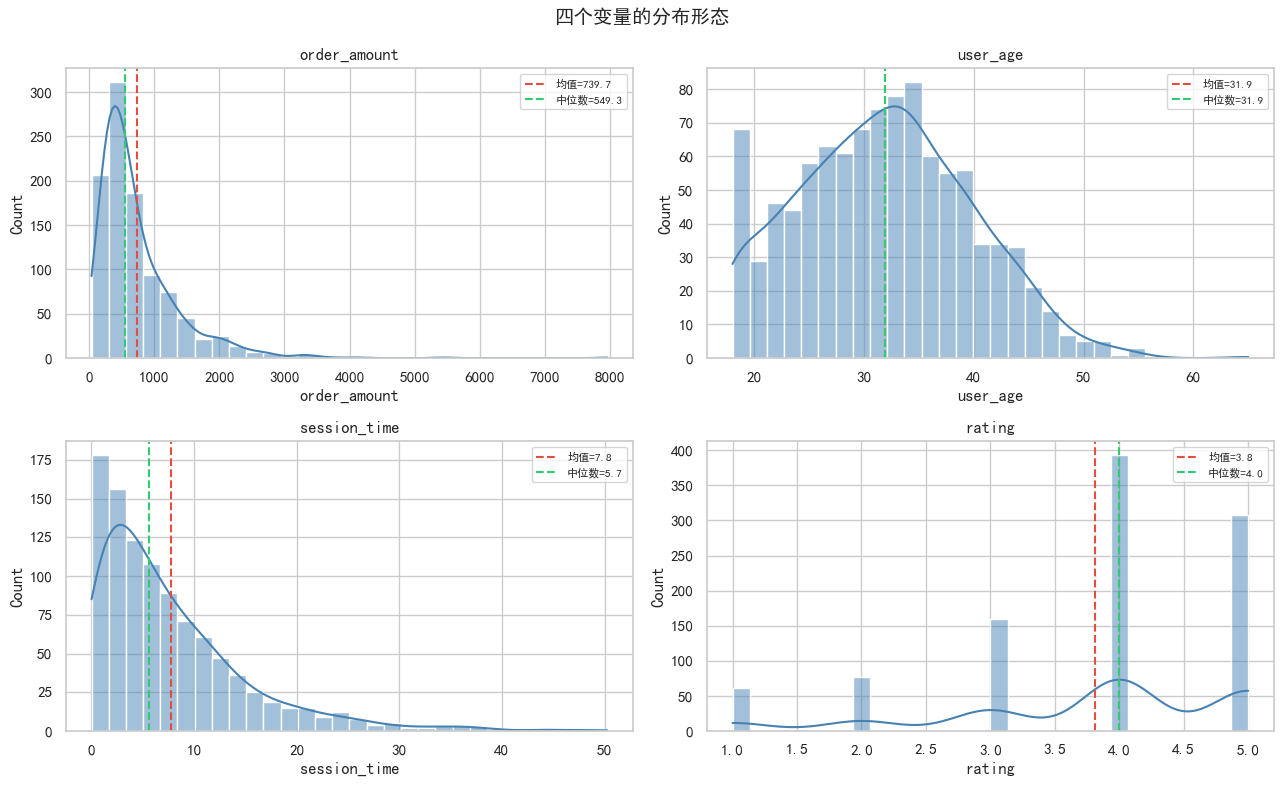

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(2024)
n = 1000

df = pd.DataFrame({
    'order_amount': np.random.lognormal(6.3, 0.75, n),
    'user_age':     np.random.normal(32, 8, n).clip(18, 65),
    'session_time': np.random.exponential(8, n),
    'rating':       np.random.choice([1,2,3,4,5], n, p=[0.05,0.08,0.15,0.42,0.30])
})

def describe_full(series, name):
    """完整描述性统计"""
    print(f"\n{'='*40}")
    print(f"变量：{name}")
    print(f"{'='*40}")
    print(f"  样本量:   {len(series)}")
    print(f"  均值:     {series.mean():.2f}")
    print(f"  中位数:   {series.median():.2f}")
    print(f"  标准差:   {series.std():.2f}")
    print(f"  变异系数: {series.std()/series.mean():.3f}")
    print(f"  最小值:   {series.min():.2f}")
    print(f"  25%:      {series.quantile(0.25):.2f}")
    print(f"  75%:      {series.quantile(0.75):.2f}")
    print(f"  最大值:   {series.max():.2f}")
    print(f"  IQR:      {series.quantile(0.75) - series.quantile(0.25):.2f}")
    print(f"  偏度:     {stats.skew(series):.3f}  {'→ 右偏' if stats.skew(series) > 0.5 else '→ 左偏' if stats.skew(series) < -0.5 else '→ 近似对称'}")
    print(f"  峰度:     {stats.kurtosis(series):.3f}  {'→ 尖峰' if stats.kurtosis(series) > 1 else '→ 平顶' if stats.kurtosis(series) < -1 else '→ 正常'}")

    # 异常值
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()
    print(f"  异常值数: {n_outliers} ({n_outliers/len(series)*100:.1f}%)")

for col in df.columns:
    describe_full(df[col], col)

# ── 可视化 ──
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, (col, ax) in enumerate(zip(df.columns, axes.flat)):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(df[col].mean(), color='#E74C3C', linestyle='--', linewidth=1.5, label=f'均值={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='#2ECC71', linestyle='--', linewidth=1.5, label=f'中位数={df[col].median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.rcParams['font.family'] = 'Segoe UI Emoji,SimHei'
plt.rcParams['font.sans-serif'] = ['SimHei']   # 黑体
plt.suptitle('四个变量的分布形态', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 六、📋 描述性统计速查

| 指标 | 含义 | 函数 |
|------|------|------|
| 均值 | 加权中心 | `np.mean()` / `.mean()` |
| 中位数 | 排序后中间值 | `np.median()` / `.median()` |
| 众数 | 出现最多的值 | `scipy.stats.mode()` |
| 标准差 | 平均偏离程度 | `np.std()` / `.std()` |
| 方差 | 标准差² | `np.var()` / `.var()` |
| 变异系数 | 标准差/均值 | 手算 |
| IQR | Q3 - Q1 | 手算 |
| 偏度 | 歪斜程度 | `scipy.stats.skew()` |
| 峰度 | 尖锐程度 | `scipy.stats.kurtosis()` |

---

## 七、📝 小结

描述性统计的三个维度：
1. **集中趋势**（数据的重心）：均值、中位数、众数
2. **离散程度**（数据的波动）：标准差、IQR、变异系数
3. **分布形态**（数据的形状）：偏度、峰度

拿到任何数据，先跑这些指标，3分钟摸清数据全貌。

---

## 八、🏋️ 课后练习

1. 对你实战项目的 `amount` 列，计算均值、中位数、标准差、偏度，判断分布形态。
2. 用 IQR 法识别 `amount` 的异常值，看有多少条？
3. 比较"普通用户"和"钻石用户"的客单价变异系数，哪组更稳定？

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 30 篇：数据分布 — 正态 / 偏态 / 长尾**
>
> 有了描述统计的基础，下篇来认识数据分布——正态分布为什么这么重要？偏态和长尾又意味着什么？

---

*跟着小荷，数据分析路上不迷路～*